#  KPIs (Indicateurs Clés)
**Projet** : Analyse des Offres d'Emploi au Sénégal — Volkeno

**KPIs analysés** :
- Compétences les plus recherchées
- Croissance mensuelle des offres
- Type de contrat dominant

##  Import des bibliothèques

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os
from collections import Counter

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 11
print('Bibliothèques importées !')

Bibliothèques importées !


## Chargement des données

In [4]:
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
FILE     = os.path.join(BASE_DIR, 'data', 'cleaned', 'offres_emploi_senegal_cleaned.csv')

df = pd.read_csv(FILE, encoding='utf-8-sig')
print(f'Données chargées : {len(df)} offres')

# Parsing des dates
MOIS = {
    'janvier': '01', 'février': '02', 'mars': '03',
    'avril': '04', 'mai': '05', 'juin': '06',
    'juillet': '07', 'août': '08', 'septembre': '09',
    'octobre': '10', 'novembre': '11', 'décembre': '12',
    'janv.': '01', 'févr.': '02', 'avr.': '04',
    'juil.': '07', 'sept.': '09', 'oct.': '10',
    'nov.': '11', 'déc.': '12',
}

def parser_date(date_str):
    if pd.isna(date_str) or date_str == 'Non précisé':
        return pd.NaT
    date_str = str(date_str).strip().lower()
    for mois_fr, mois_num in MOIS.items():
        if mois_fr in date_str:
            date_str = date_str.replace(mois_fr, mois_num)
            break
    try:
        return pd.to_datetime(date_str, dayfirst=True)
    except:
        return pd.NaT

df['Date parsed'] = df['Date de publication'].apply(parser_date)
df['Mois']        = df['Date parsed'].dt.to_period('M')
print(f'Dates parsées : {df["Date parsed"].notna().sum()} / {len(df)}')

Données chargées : 3332 offres
Dates parsées : 3315 / 3332


## -- Compétences les plus recherchées

TOP 15 COMPÉTENCES LES PLUS RECHERCHÉES
         Compétence  Fréquence
              Vente        397
       Informatique        385
          Formation        373
          Recherche        306
            Finance        248
      Communication        192
        Recrutement        155
       Comptabilité        148
         Management        146
          Marketing        136
         Logistique        116
              Excel        115
               Sage        106
           Français         86
Ressources Humaines         85


C:\Users\Users\AppData\Local\Temp\ipykernel_17716\3824944168.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_competences, x='Compétence', y='Fréquence', palette='Oranges_r', ax=ax)


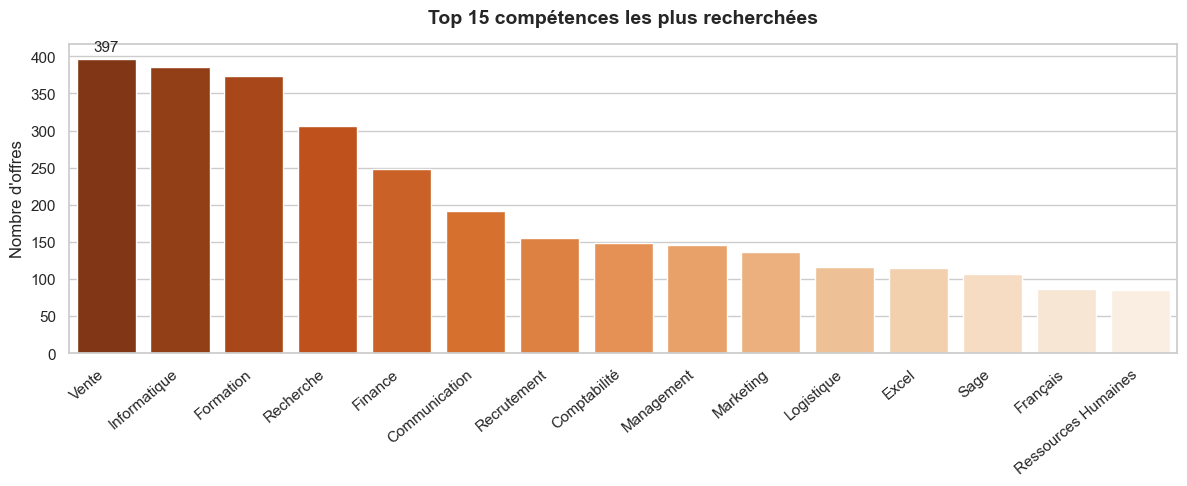

Graphique sauvegardé : kpi_competences.png


In [5]:
# Domaines de compétences à rechercher
COMPETENCES_CLES = {
    # Informatique & Tech
    'Excel': ['excel'],
    'Word': ['word'],
    'PowerPoint': ['powerpoint', 'power point'],
    'Python': ['python'],
    'SQL': ['sql'],
    'SAP': ['sap'],
    'ERP': ['erp'],
    'CRM': ['crm'],
    'Sage': ['sage'],
    'AutoCAD': ['autocad'],
    'Pack Office': ['pack office', 'office 365', 'microsoft office'],

    # Compétences transversales
    'Communication': ['communication', 'communicat'],
    'Management': ['management', 'manager', 'managérial'],
    'Comptabilité': ['comptabilité', 'comptable', 'compta'],
    'Finance': ['finance', 'financier', 'financière'],
    'Marketing': ['marketing', 'digital marketing'],
    'Vente': ['vente', 'commercial', 'commerciale'],
    'Ressources Humaines': ['ressources humaines', 'rh ', ' rh,'],
    'Juridique': ['juridique', 'droit', 'legal'],
    'Logistique': ['logistique', 'supply chain'],
    'Anglais': ['anglais', 'english'],
    'Français': ['français', 'french'],
    'Rédaction': ['rédaction', 'rédiger'],
    'Analyse de données': ['analyse des données', 'data analysis', 'analyse de données'],
    'Gestion de projet': ['gestion de projet', 'project management', 'chef de projet'],
    'Service client': ['service client', 'relation client', 'customer'],
    'Recherche': ['recherche', 'research'],
    'Formation': ['formation', 'training'],
    'Recrutement': ['recrutement', 'recruitment'],
    'Audit': ['audit', 'auditeur'],
    'Informatique': ['informatique', 'it ', ' it,'],
}

# Comptage
comptage = {}
for label, keywords in COMPETENCES_CLES.items():
    count = 0
    for comp in df['Compétences demandées'].dropna():
        if comp == 'Non précisé':
            continue
        comp_lower = comp.lower()
        if any(kw in comp_lower for kw in keywords):
            count += 1
    if count > 0:
        comptage[label] = count

# Top 15
top_competences = (
    pd.DataFrame(list(comptage.items()), columns=['Compétence', 'Fréquence'])
    .sort_values('Fréquence', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print('TOP 15 COMPÉTENCES LES PLUS RECHERCHÉES')
print('=' * 40)
print(top_competences.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=top_competences, x='Compétence', y='Fréquence', palette='Oranges_r', ax=ax)
ax.set_title('Top 15 compétences les plus recherchées', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Nombre d\'offres')
ax.bar_label(ax.containers[0], fmt='%d', padding=3)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('kpi_competences.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : kpi_competences.png')

## -- Croissance mensuelle des offres

 CROISSANCE MENSUELLE DES OFFRES
Mois str  Nombre d'offres  Croissance (%)
 2024-07               68             NaN
 2024-08               19      -72.058824
 2024-09               26       36.842105
 2024-10               44       69.230769
 2024-11               38      -13.636364
 2024-12                8      -78.947368
 2025-01              210     2525.000000
 2025-02              234       11.428571
 2025-03              230       -1.709402
 2025-04              265       15.217391
 2025-05              203      -23.396226
 2025-06              242       19.211823
 2025-07              212      -12.396694
 2025-08              148      -30.188679
 2025-09              200       35.135135
 2025-10              286       43.000000
 2025-11              111      -61.188811
 2025-12              208       87.387387
 2026-01              243       16.826923
 2026-02              202      -16.872428
 2026-03              118      -41.584158

-- Croissance moyenne  : 125.4% / mois
-- 

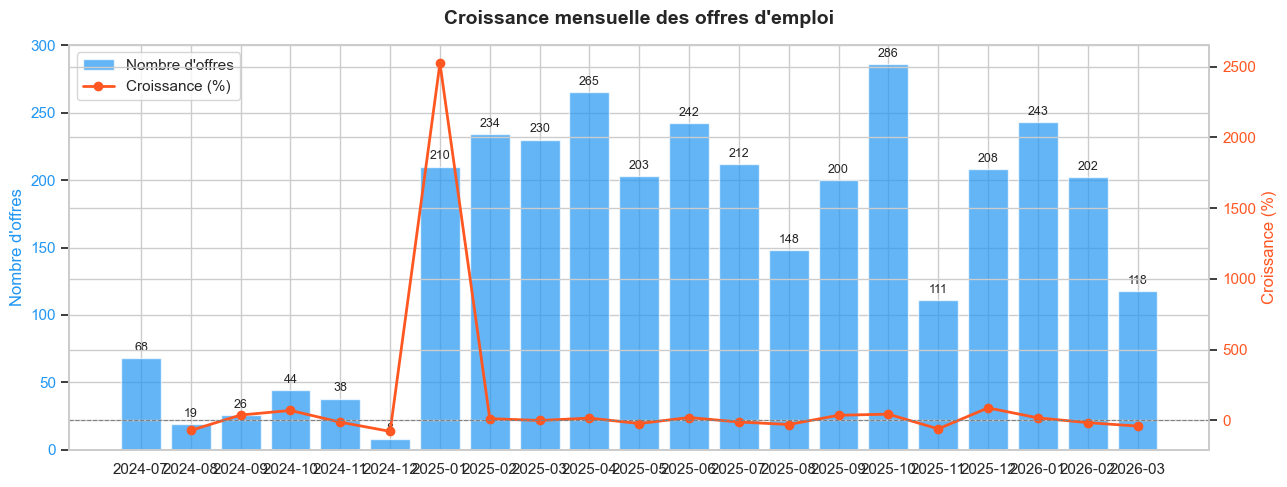

Graphique sauvegardé : kpi_croissance_mensuelle.png


In [6]:
evolution = (
    df[df['Mois'].notna()]
    .groupby('Mois')
    .size()
    .reset_index(name="Nombre d'offres")
    .sort_values('Mois')
)

# Calcul croissance mensuelle
evolution['Croissance (%)'] = evolution["Nombre d'offres"].pct_change() * 100
evolution['Mois str']       = evolution['Mois'].astype(str)

print(' CROISSANCE MENSUELLE DES OFFRES')
print('=' * 40)
print(evolution[['Mois str', "Nombre d'offres", 'Croissance (%)']].to_string(index=False))

# KPI global
croissance_moy = evolution['Croissance (%)'].mean()
mois_pic       = evolution.loc[evolution["Nombre d'offres"].idxmax(), 'Mois str']
nb_pic         = evolution["Nombre d'offres"].max()
print(f'\n-- Croissance moyenne  : {croissance_moy:.1f}% / mois')
print(f'-- Mois le plus actif  : {mois_pic} ({nb_pic} offres)')

# Visualisation
fig, ax1 = plt.subplots(figsize=(13, 5))

# Barres — nombre d'offres
bars = ax1.bar(evolution['Mois str'], evolution["Nombre d'offres"],
               color='#2196F3', alpha=0.7, label="Nombre d'offres")
ax1.set_ylabel("Nombre d'offres", color='#2196F3')
ax1.tick_params(axis='y', labelcolor='#2196F3')
ax1.bar_label(bars, fmt='%d', padding=3, fontsize=9)

# Ligne — croissance
ax2 = ax1.twinx()
ax2.plot(evolution['Mois str'], evolution['Croissance (%)'],
         color='#FF5722', marker='o', linewidth=2, label='Croissance (%)')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_ylabel('Croissance (%)', color='#FF5722')
ax2.tick_params(axis='y', labelcolor='#FF5722')

ax1.set_title('Croissance mensuelle des offres d\'emploi', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('')
plt.xticks(rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('kpi_croissance_mensuelle.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : kpi_croissance_mensuelle.png')

## -- Type de contrat dominant

 TYPE DE CONTRAT DOMINANT
Type de contrat  Nombre  Pourcentage
    Temps plein    2615         79.5
            CDD     480         14.6
            CDI     110          3.3
          Stage      70          2.1
      Freelance       6          0.2
     Alternance       4          0.1
        Intérim       3          0.1

Contrat dominant : Temps plein (79.5%)


C:\Users\Users\AppData\Local\Temp\ipykernel_17716\626075505.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contrats, x='Type de contrat', y='Nombre', palette='Set2', ax=ax1)


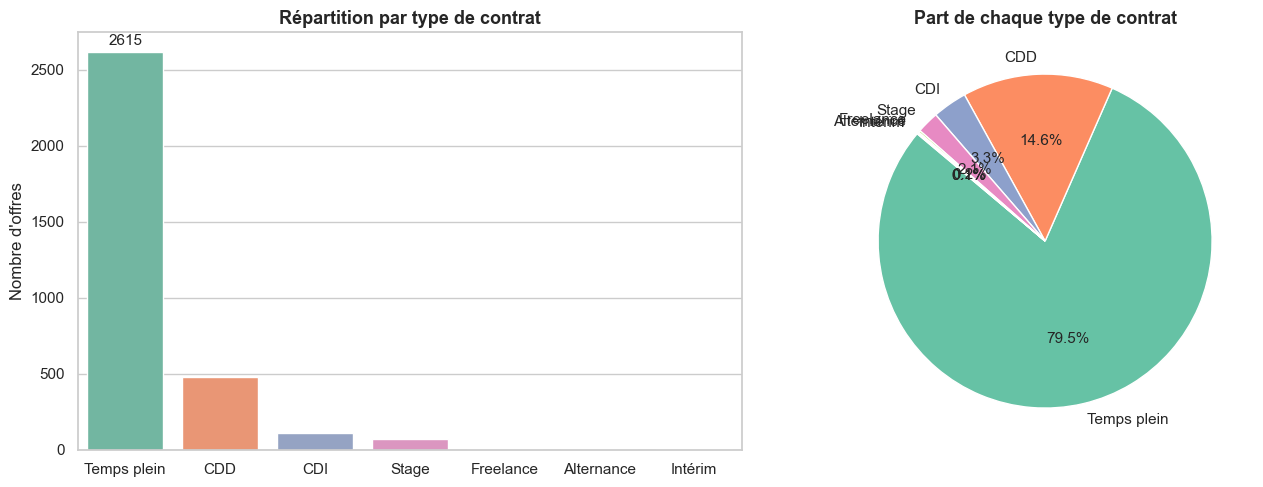

Graphique sauvegardé : kpi_contrats.png


In [7]:
contrats = (
    df[df['Type de contrat'] != 'Non précisé']['Type de contrat']
    .value_counts()
    .reset_index()
)
contrats.columns = ['Type de contrat', 'Nombre']
contrats['Pourcentage'] = (contrats['Nombre'] / contrats['Nombre'].sum() * 100).round(1)

# KPI global
dominant = contrats.iloc[0]
print(' TYPE DE CONTRAT DOMINANT')
print('=' * 40)
print(contrats.to_string(index=False))
print(f'\nContrat dominant : {dominant["Type de contrat"]} ({dominant["Pourcentage"]}%)')

# Visualisation — barplot + camembert côte à côte
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Barplot
sns.barplot(data=contrats, x='Type de contrat', y='Nombre', palette='Set2', ax=ax1)
ax1.set_title('Répartition par type de contrat', fontsize=13, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Nombre d\'offres')
ax1.bar_label(ax1.containers[0], fmt='%d', padding=3)

# Camembert
colors = sns.color_palette('Set2', len(contrats))
ax2.pie(
    contrats['Nombre'],
    labels=contrats['Type de contrat'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)
ax2.set_title('Part de chaque type de contrat', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('kpi_contrats.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : kpi_contrats.png')

## Nombre total d'offres scrappées 

 NOMBRE TOTAL D'OFFRES SCRAPPÉES
Total d'offres : 3332


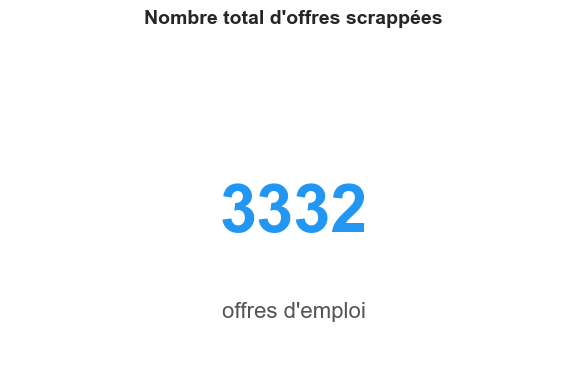

Graphique sauvegardé : kpi_total_offres.png


In [8]:
# Nombre total d'offres scrappées
total_offres = len(df)

print(" NOMBRE TOTAL D'OFFRES SCRAPPÉES")
print("=" * 40)
print(f"Total d'offres : {total_offres}")

# Visualisation
fig, ax = plt.subplots(figsize=(6, 4))
ax.text(0.5, 0.5, f"{total_offres}", 
        horizontalalignment='center', verticalalignment='center',
        fontsize=48, fontweight='bold', color='#2196F3')
ax.text(0.5, 0.2, "offres d'emploi", 
        horizontalalignment='center', verticalalignment='center',
        fontsize=16, color='#555555')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title("Nombre total d'offres scrappées", fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('kpi_total_offres.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : kpi_total_offres.png')

## Ville avec le plus d'opportunités

 VILLE AVEC LE PLUS D'OPPORTUNITÉS
Dakar : 3209 offres
Soit 96.3% du total


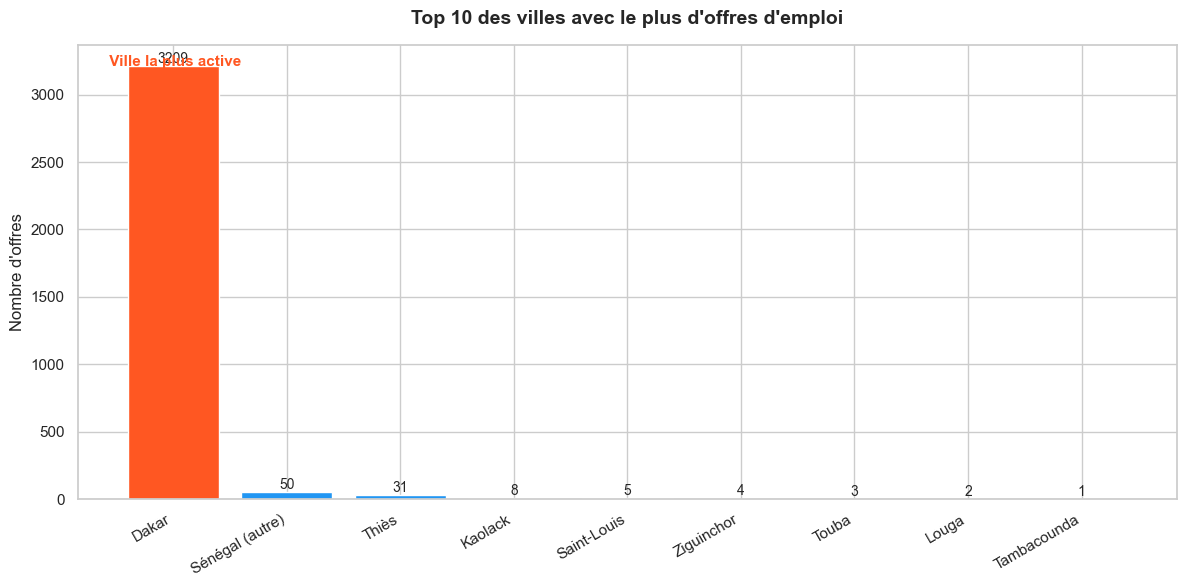

Graphique sauvegardé : kpi_top_villes.png

TOP 10 DES VILLES
----------------------------------------
 Dakar                3209 offres
 Sénégal (autre)       50 offres
 Thiès                 31 offres
   Kaolack                8 offres
   Saint-Louis            5 offres
   Ziguinchor             4 offres
   Touba                  3 offres
   Louga                  2 offres
   Tambacounda            1 offres


In [10]:
villes = (
    df[df['Ville'] != 'Non précisé']['Ville']
    .value_counts()
    .reset_index()
)
villes.columns = ['Ville', "Nombre d'offres"]

top_ville = villes.iloc[0]

print(" VILLE AVEC LE PLUS D'OPPORTUNITÉS")
print("=" * 40)
print(f"{top_ville['Ville']} : {top_ville['Nombre d\'offres']} offres")
print(f"Soit {top_ville['Nombre d\'offres']/total_offres*100:.1f}% du total")

# Visualisation - Top 10 des villes
fig, ax = plt.subplots(figsize=(12, 6))

top10_villes = villes.head(10)
colors = ['#FF5722' if i == 0 else '#2196F3' for i in range(len(top10_villes))]

bars = ax.bar(range(len(top10_villes)), top10_villes["Nombre d'offres"], color=colors)
ax.set_xticks(range(len(top10_villes)))
ax.set_xticklabels(top10_villes['Ville'], rotation=30, ha='right')
ax.set_ylabel("Nombre d'offres")
ax.set_title("Top 10 des villes avec le plus d'offres d'emploi", fontsize=14, fontweight='bold', pad=15)

# Ajout des valeurs
for i, (bar, val) in enumerate(zip(bars, top10_villes["Nombre d'offres"])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{int(val)}', ha='center', va='bottom', fontsize=10)

# Mise en évidence de la ville en tête
ax.text(0, top10_villes.iloc[0]["Nombre d'offres"] + 5, 
        " Ville la plus active", 
        ha='center', fontsize=11, fontweight='bold', color='#FF5722')

plt.tight_layout()
plt.savefig('kpi_top_villes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : kpi_top_villes.png')

# Carte simple des top villes (texte uniquement, sans folium pour éviter les dépendances)
print("\nTOP 10 DES VILLES")
print("-" * 40)
for i, row in top10_villes.iterrows():
    medal = "" if i == 0 else "" if i == 1 else "" if i == 2 else "  "
    print(f"{medal} {row['Ville']:<20} {int(row['Nombre d\'offres']):3d} offres")

## Secteur dominant 

 SECTEUR D'ACTIVITÉ DOMINANT
Informatique / IT : 638 offres
Soit 25.6% des offres sectorisées


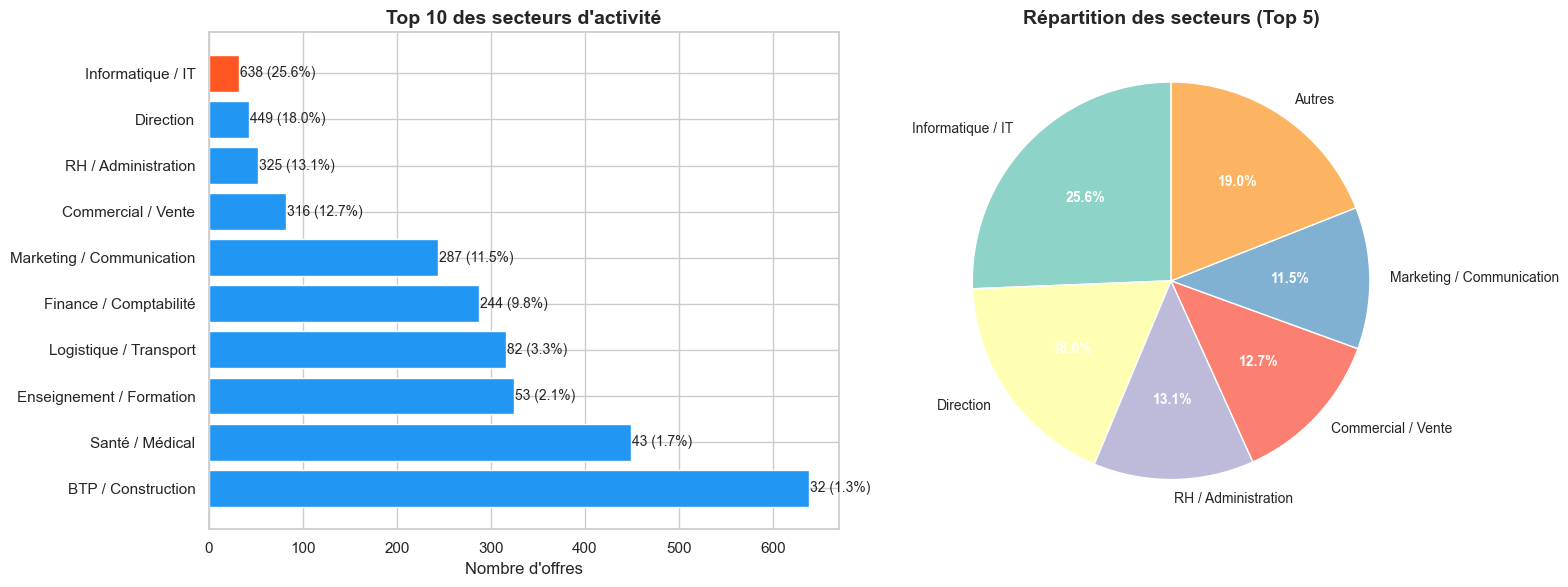

Graphique sauvegardé : kpi_secteurs_dominants.png

 TOP 10 DES SECTEURS
--------------------------------------------------
 Informatique / IT         638 offres (25.6%)
 Direction                 449 offres (18.0%)
 RH / Administration       325 offres (13.1%)
   Commercial / Vente        316 offres (12.7%)
   Marketing / Communication 287 offres (11.5%)
   Finance / Comptabilité    244 offres (9.8%)
   Logistique / Transport     82 offres (3.3%)
   Enseignement / Formation   53 offres (2.1%)
   Santé / Médical            43 offres (1.7%)
   BTP / Construction         32 offres (1.3%)

 Les 3 secteurs principaux représentent 56.8% des offres sectorisées


In [11]:
secteurs = (
    df[df['Catégorie'] != 'Non précisé']['Catégorie']
    .value_counts()
    .reset_index()
)
secteurs.columns = ['Secteur', "Nombre d'offres"]
secteurs['Pourcentage'] = (secteurs["Nombre d'offres"] / secteurs["Nombre d'offres"].sum() * 100).round(1)

top_secteur = secteurs.iloc[0]

print(" SECTEUR D'ACTIVITÉ DOMINANT")
print("=" * 40)
print(f"{top_secteur['Secteur']} : {top_secteur['Nombre d\'offres']} offres")
print(f"Soit {top_secteur['Pourcentage']}% des offres sectorisées")

# Visualisation - Top 10 des secteurs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot horizontal
top10_secteurs = secteurs.head(10)
colors = ['#FF5722' if i == 0 else '#2196F3' for i in range(len(top10_secteurs))]

bars = axes[0].barh(range(len(top10_secteurs)), top10_secteurs["Nombre d'offres"], color=colors[::-1])
axes[0].set_yticks(range(len(top10_secteurs)))
axes[0].set_yticklabels(top10_secteurs['Secteur'][::-1])
axes[0].set_xlabel("Nombre d'offres")
axes[0].set_title("Top 10 des secteurs d'activité", fontsize=14, fontweight='bold')

# Ajout des valeurs
for i, (bar, val) in enumerate(zip(bars, top10_secteurs["Nombre d'offres"][::-1])):
    width = bar.get_width()
    axes[0].text(width + 1, bar.get_y() + bar.get_height()/2,
                f'{int(val)} ({top10_secteurs["Pourcentage"].iloc[len(top10_secteurs)-1-i]}%)', 
                va='center', fontsize=10)

# Camembert
top5_secteurs = secteurs.head(5)
autres = secteurs.iloc[5:]["Nombre d'offres"].sum()
pie_data = pd.concat([
    top5_secteurs.set_index('Secteur')["Nombre d'offres"], 
    pd.Series({'Autres': int(autres)})
])

colors_pie = sns.color_palette('Set3', len(pie_data))
wedges, texts, autotexts = axes[1].pie(
    pie_data.values, 
    labels=pie_data.index, 
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    textprops={'fontsize': 10}
)

# Améliorer l'apparence des pourcentages
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

axes[1].set_title('Répartition des secteurs (Top 5)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('kpi_secteurs_dominants.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : kpi_secteurs_dominants.png')

# Affichage détaillé
print("\n TOP 10 DES SECTEURS")
print("-" * 50)
for i, row in top10_secteurs.iterrows():
    medal = "" if i == 0 else "" if i == 1 else "" if i == 2 else "  "
    print(f"{medal} {row['Secteur']:<25} {int(row['Nombre d\'offres']):3d} offres ({row['Pourcentage']}%)")

# Analyse supplémentaire : concentration
top3_percent = secteurs.head(3)["Nombre d'offres"].sum() / secteurs["Nombre d'offres"].sum() * 100
print(f"\n Les 3 secteurs principaux représentent {top3_percent:.1f}% des offres sectorisées")

## Résumé des KPIs

In [14]:
print("\n" + "="*60)
print("RÉSUMÉ DES INDICATEURS CLÉS (KPIs)")
print("="*60)

# KPI 1: Total offres
print(f"\n NOMBRE TOTAL D'OFFRES : {total_offres}")

# KPI 2: Compétence la plus demandée
if 'top_competences' in locals() and len(top_competences) > 0:
    top_comp = top_competences.iloc[0]
    print(f"\n COMPÉTENCE LA PLUS RECHERCHÉE : {top_comp['Compétence']} ({top_comp['Fréquence']} offres)")

# KPI 3: Croissance mensuelle moyenne
if 'croissance_moy' in locals():
    print(f"\n CROISSANCE MENSUELLE MOYENNE : {croissance_moy:.1f}%")

# KPI 4: Type de contrat dominant
if 'dominant' in locals():
    print(f"\n TYPE DE CONTRAT DOMINANT : {dominant['Type de contrat']} ({dominant['Pourcentage']}%)")

# KPI 5: Ville la plus active
if 'top_ville' in locals():
    print(f"\n VILLE LA PLUS ACTIVE : {top_ville['Ville']} ({top_ville['Nombre d\'offres']} offres)")

# KPI 6: Secteur dominant
if 'top_secteur' in locals():
    print(f"\n SECTEUR DOMINANT : {top_secteur['Secteur']} ({top_secteur['Nombre d\'offres']} offres, {top_secteur['Pourcentage']}%)")

print("\n" + "="*60)


RÉSUMÉ DES INDICATEURS CLÉS (KPIs)

 NOMBRE TOTAL D'OFFRES : 3332

 COMPÉTENCE LA PLUS RECHERCHÉE : Vente (397 offres)

 CROISSANCE MENSUELLE MOYENNE : 125.4%

 TYPE DE CONTRAT DOMINANT : Temps plein (79.5%)

 VILLE LA PLUS ACTIVE : Dakar (3209 offres)

 SECTEUR DOMINANT : Informatique / IT (638 offres, 25.6%)

